
# **Home Credit Default Risk**


ce projet s'inscrit dans le cadre du domaine financier et a pour objectif de developper un modele de SCORING DE RISQUES DE CREDIT. 


les banques et institutions financieres doivent evaluer avecc precision la probabilite de defaut de paiement d'un client avant d'accorder un credit.


l'enjeu est donc de MINIMISER LES RISQUES DE NON-REMBOURSSEMENT tout en maintenant une politique de pret equitable et competitive.


---

    notre objectif en tant qu'ingenieur de la donnee est de PREDIRE LA PROBABILITE QU'UN CLIENT NE REMBOURSE PAS SON CREDIT a partir de donnees socio-economiques, historiques et comportementales

---



### **Dataset :** 

le projet utilise le dataset Home Credit Default Risk, disponible sur kaggle:

**ce dataset contient :**
- des informations sur les clients (age, emploi, revenu,...)
- des historiques de credit anterieurs
- des donnees comportementales et de REMBOURSSEMENT
- des informations sur les demandes de credit en cours


---

### **RICHESSE ET DEFIS POUR L'EDA (EXPLORATORY DATA ANALYSIS) :**

- **VARIABLES SOCIO-ECONOMIQUES VARIEES :** permetant une analyse multidimensionnelle du profil de l'emprunteur

- **VALEURS MANQUANTES COMPLEXES :** necessitant des strategies de traitement avancees (imputation, suppression,modelisation)

- **ANALYSE DES BIAIS :** identification des biais potentiels dans les donnees pouvant affeccter l'equiter du modele (genre, age, origine,...)

- **DESEQUILIBRE DES CLASSES :** le nombre de bons payeurs est generalement superieur a celui des mauvais payeurs, ce qui requiert des techniques de reequilibrage


---

### **ETAPE DE REALISATION DU PROJET:**

**1- ANALYSE EXPLORATOIRE (EDA) ET PRETRAITEMENT :**
- analyse des distributions, correlations et valeurs aberantes.
- gestion des valeurs manquantes.
- Features engineering pour creer des variables explicatives pertinantes.

**2- IMPLEMENTATION DU MODELE :**
- test de plusieurs algorithmes (regression logisstique, forets aleatoires, XGBoost, LightGBM,...)
- optimisation des hyperparametres.
- validation croisee pour assurer la robustesse du modele.

**3- INTERPRETATION ET EVALUATION :** 
- METRIQUES CLES : auc-roc, PRECISION, RAPPEL, f1-SCORE
- analyse des features importantes
- explicabilite du modele (SHAP, LIME)

**4- deploiement et monitoring (MLOps)**
- packaging du modele
- creation d'une API de prediction
- mise en place de pipelines de reentrainement et de monitoring des performances

---

### **STRUCTURE DU PROJET**

- `data/application_train.csv :` contient des fonctions pour charger et prétraiter les données.

- `notebook/notebook.ipynb :` contient des fonctions utilitaires (ex: évaluation, visualisation).

- `src/app.py :` contient le code pour entraîner un modèle.

- `README.md :` contient le code pour faire des prédictions avec un modèle entraîné
- `requirement.txt :`

---


# **CHARGEMENT DES DONNEES**

In [20]:

from my_bibliotheque import *

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.calibration import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier



import sys 
import os


df = pd.read_csv('application_train.csv') 
df_safe = df.copy
print("*****************dataset chargee avec succes********************")

# detection des biais
print(f"repartition par classe (TARGET):")
print(df['TARGET'].value_counts(normalize=True))



*****************dataset chargee avec succes********************
repartition par classe (TARGET):
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64



---

# **1- ANALYSE EXPLORATOIRE (EDA) & PRETRAITEMENT :**
- analyse des distributions, correlations et valeurs aberantes.
- gestion des valeurs manquantes et aberantes
- Features engineering 

---


---

## **description :**
a cette etape il est question de prendre connaissance des differentes specificiter et caracteristiques de notre jeu de donnees, on va nottament :
- identifer la presence des valeurs `manquantes` et `aberantes`
- traiter les valeurs manquantes s'il y en a a travers la methode la plus approprier en fonction de la situation
- visualiser et identifier les features les plus importantes (les lus `correlees` avec la target ) afin de ce focaliser sur ces dernieres dans les prochaine etapes
- visualiser et identifier les features 

---

# **1.1- analyse des distributions :**

In [21]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


#### **NOTES :**
nous allons commencer par supprimer la colonne SK_ID_CURR cars nous estimons qu'elle n'apporte aucune valeur ajoouter a l'echantillon

In [22]:
df=df.drop(columns="SK_ID_CURR", axis=1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 121 entries, TARGET to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 283.9+ MB


In [24]:
df.columns

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=121)

In [25]:
df.dtypes

TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
FLAG_OWN_REALTY                object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 121, dtype: object

Text(0.5, 1.0, 'Distribution de la variable cible ')

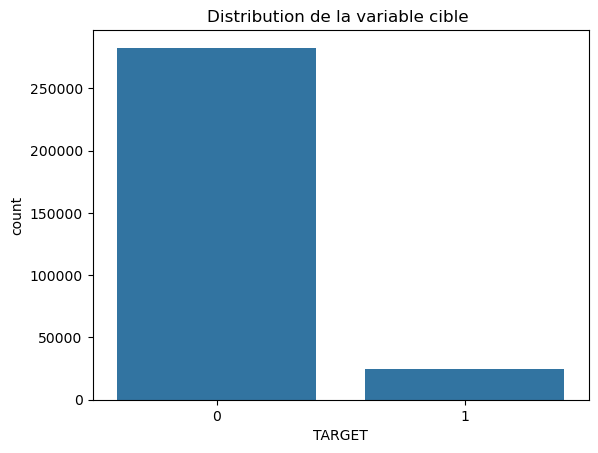

In [26]:
# distribution de la variable cible
sns.countplot(x='TARGET', data=df)
plt.title('Distribution de la variable cible ')

In [27]:
# statististique descriptives

df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [28]:
df.shape

(307511, 121)

In [29]:
#Biai de mesure : donnees manquantes = probleme de collecte
print(f"\n **** VALEURS MANQUANTES ****")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
print(pd.DataFrame({'Missing': missing, 'Pourcentage': missing_pct}))


 **** VALEURS MANQUANTES ****
                            Missing  Pourcentage
TARGET                            0     0.000000
NAME_CONTRACT_TYPE                0     0.000000
CODE_GENDER                       0     0.000000
FLAG_OWN_CAR                      0     0.000000
FLAG_OWN_REALTY                   0     0.000000
...                             ...          ...
AMT_REQ_CREDIT_BUREAU_DAY     41519    13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    41519    13.501631
AMT_REQ_CREDIT_BUREAU_MON     41519    13.501631
AMT_REQ_CREDIT_BUREAU_QRT     41519    13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    41519    13.501631

[121 rows x 2 columns]


In [30]:
def afficher_valeurs_manquantes(df):
    """
    Affiche les colonnes ayant des valeurs manquantes
    
    parametres : 
    df(DataFrame) : le dtaframe a analyser
    """

    for colonne in df.columns:
        nb_valeurs_manquantes = df[colonne].isnull().sum()

        if nb_valeurs_manquantes > 0:
            print(f"colonne : {colonne}")
            print(f"nombres de valeurs manquantes : {nb_valeurs_manquantes}")
            print(f"pourcentage de valeurs manquantes : {(df[colonne].isnull().sum() / len(df)) * 100:.2f}%")
            print("-----------------------------------------------")

In [31]:
afficher_valeurs_manquantes(df)

colonne : AMT_ANNUITY
nombres de valeurs manquantes : 12
pourcentage de valeurs manquantes : 0.00%
-----------------------------------------------
colonne : AMT_GOODS_PRICE
nombres de valeurs manquantes : 278
pourcentage de valeurs manquantes : 0.09%
-----------------------------------------------
colonne : NAME_TYPE_SUITE
nombres de valeurs manquantes : 1292
pourcentage de valeurs manquantes : 0.42%
-----------------------------------------------
colonne : OWN_CAR_AGE
nombres de valeurs manquantes : 202929
pourcentage de valeurs manquantes : 65.99%
-----------------------------------------------
colonne : OCCUPATION_TYPE
nombres de valeurs manquantes : 96391
pourcentage de valeurs manquantes : 31.35%
-----------------------------------------------
colonne : CNT_FAM_MEMBERS
nombres de valeurs manquantes : 2
pourcentage de valeurs manquantes : 0.00%
-----------------------------------------------
colonne : EXT_SOURCE_1
nombres de valeurs manquantes : 173378
pourcentage de valeurs manqua

traitement des valeurs manquantes

In [62]:
def traiter_valeurs_manquantes(df):
    """
    Traite les valeurs manquantes dans un DataFrame.
    Paramètres :
    df (DataFrame) : Le DataFrame à traiter.
    Retourne :
    df_traite (DataFrame) : Le DataFrame traité.
    """
    df_traite = df.copy()
    # Boucle sur les colonnes du DataFrame
    for colonne in df_traite.columns:
        # Compte le nombre de valeurs manquantes dans la colonne
        nb_valeurs_manquantes = df_traite[colonne].isnull().sum()
        # Pourcentage de valeurs manquantes
        pourcentage_valeurs_manquantes = (nb_valeurs_manquantes / len(df_traite)) * 100
        # Si le pourcentage de valeurs manquantes est inférieur à 5%, supprime les lignes
        if pourcentage_valeurs_manquantes < 5:
            df_traite = df_traite.dropna(subset=[colonne])
        # Si le pourcentage de valeurs manquantes est supérieur ou égal à 5%, impute les valeurs manquantes
        else:
            if df_traite[colonne].dtype == 'object':
                imputer = SimpleImputer(strategy='most_frequent')
            else:
                imputer = SimpleImputer(strategy='mean')
                
            df_traite[colonne] = imputer.fit_transform(df_traite[[colonne]])
    return df_traite


In [ ]:
#df_traite = df.copy()
# # Boucle sur les colonnes du DataFrame
# for colonne in df_traite.columns:
#     # Compte le nombre de valeurs manquantes dans la colonne
#     nb_valeurs_manquantes = df_traite[colonne].isnull().sum()
#     # Pourcentage de valeurs manquantes
#     pourcentage_valeurs_manquantes = (nb_valeurs_manquantes / len(df_traite)) * 100
#     # Si le pourcentage de valeurs manquantes est inférieur à 5%, supprime les lignes
#     if pourcentage_valeurs_manquantes < 5:
#         df_traite = df_traite.dropna(subset=[colonne])
#         # Si le pourcentage de valeurs manquantes est supérieur ou égal à 5%, impute les valeurs manquantes
#     else:
#         if df_traite[colonne].dtype == 'object':
#             imputer = SimpleImputer(strategy='most_frequent')
#         else:
#             imputer = SimpleImputer(strategy='mean')
#             df_traite[colonne] = imputer.fit_transform(df_traite[[colonne]])


df_traite = traiter_valeurs_manquantes(df)

ValueError: 2

In [60]:
afficher_valeurs_manquantes(df_traite)

colonne : OCCUPATION_TYPE
nombres de valeurs manquantes : 95435
pourcentage de valeurs manquantes : 31.34%
-----------------------------------------------
colonne : FONDKAPREMONT_MODE
nombres de valeurs manquantes : 208352
pourcentage de valeurs manquantes : 68.42%
-----------------------------------------------
colonne : HOUSETYPE_MODE
nombres de valeurs manquantes : 152937
pourcentage de valeurs manquantes : 50.22%
-----------------------------------------------
colonne : WALLSMATERIAL_MODE
nombres de valeurs manquantes : 154978
pourcentage de valeurs manquantes : 50.89%
-----------------------------------------------
colonne : EMERGENCYSTATE_MODE
nombres de valeurs manquantes : 144475
pourcentage de valeurs manquantes : 47.44%
-----------------------------------------------


#### **NOTES :**

a present que notre echantillon a ete nettoyer de toute valeurs manquantes nous allons poursuivre le reste de l'analyse en utilisant `df_traite` 

Cela dit nous devons encore : 
- gerer les valeurs aberantes
- identifier les features les plus importantes


---

### **OBSERVATION :**
    compte tenu du nombre important de features (106 numeric et 16 categoriels) il serait judicieux de ce demander quelles sont celles qui influences le plus nomtre variables expliquer

---

In [35]:
# identification des colonnes de types objects

colonnes_object = df_traite.select_dtypes(include=['object']).columns 

# selection des donnees des colonnes objet

donnes_objet = df_traite[colonnes_object]

In [36]:
print(colonnes_object)

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')


### **OBSERVATION :** 

nous allons observer chacune des variables de type objet present dans notre jeu de donnees afin de choisir la meilleur technique pour les traiter

In [37]:
for col in colonnes_object : 
    print("*"*20)
    print(col)
    print(df[col])

********************
NAME_CONTRACT_TYPE
0              Cash loans
1              Cash loans
2         Revolving loans
3              Cash loans
4              Cash loans
               ...       
307506         Cash loans
307507         Cash loans
307508         Cash loans
307509         Cash loans
307510         Cash loans
Name: NAME_CONTRACT_TYPE, Length: 307511, dtype: object
********************
CODE_GENDER
0         M
1         F
2         M
3         F
4         M
         ..
307506    M
307507    F
307508    F
307509    F
307510    F
Name: CODE_GENDER, Length: 307511, dtype: object
********************
FLAG_OWN_CAR
0         N
1         N
2         Y
3         N
4         N
         ..
307506    N
307507    N
307508    N
307509    N
307510    N
Name: FLAG_OWN_CAR, Length: 307511, dtype: object
********************
FLAG_OWN_REALTY
0         Y
1         N
2         Y
3         Y
4         Y
         ..
307506    N
307507    Y
307508    Y
307509    Y
307510    N
Name: FLAG_OWN_REAL

In [38]:
df_categorical_only = df_traite.select_dtypes(include=['object'])

print(df_categorical_only)

       NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0              Cash loans           M            N               Y   
1              Cash loans           F            N               N   
2         Revolving loans           M            Y               Y   
3              Cash loans           F            N               Y   
4              Cash loans           M            N               Y   
...                   ...         ...          ...             ...   
307506         Cash loans           M            N               N   
307507         Cash loans           F            N               Y   
307508         Cash loans           F            N               Y   
307509         Cash loans           F            N               Y   
307510         Cash loans           F            N               N   

       NAME_TYPE_SUITE      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0        Unaccompanied               Working  Secondary / secondary special   
1

In [39]:
df_numeric_only = df_traite.select_dtypes(include=['float','int'])

print(df_numeric_only)

        TARGET  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0            1             0          202500.0    406597.5      24700.5   
1            0             0          270000.0   1293502.5      35698.5   
2            0             0           67500.0    135000.0       6750.0   
3            0             0          135000.0    312682.5      29686.5   
4            0             0          121500.0    513000.0      21865.5   
...        ...           ...               ...         ...          ...   
307506       0             0          157500.0    254700.0      27558.0   
307507       0             0           72000.0    269550.0      12001.5   
307508       0             0          153000.0    677664.0      29979.0   
307509       1             0          171000.0    370107.0      20205.0   
307510       0             0          157500.0    675000.0      49117.5   

        AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  DAYS_BIRTH  \
0              351000.0         

### **OBSERVTION :**

nous allons a present essayer d'indentifier quelles sont les variables avec la plus grande variances

mais notre jeu de donnees est encore constituer en partie de variables categoriel (dont le type est object) 

Et nous ne voulons encoder les variables qu'a l'etapes de preproessing, il serait donc interessant de pouvoir gerer la selection des variables/features les plus importantes pour ceux de type numerique d'une part et pour ceux de type categoriel d'autre part

pour ce faire nous implementerons une fonction nommee selection_variables_importantes ()

cette fonction utilises la bibliotheques pandas pour selectionner les variables les plus importantes en fonction de metriques telsques la variance et skewness

In [40]:
def selectionner_variables_object_importantes (df):
    """
    Selectionne les variables de types object les plus importantes en fonction de la variances et du skewness

    parametres :
    df(dataframe) : le dataframe contenant les donnees

    Retourne :
    variables_importantes (list) : la liste des variables les plus importantes
    """

    # selection des colonnes object
    colonnes_objet = df.select_dtypes(include=['object']).columns

    #calcul de la variances et du skeweness pur chaque colonne pbjet
    variances = []
    skewness = []
    for colonne in colonnes_objet:
        # Encodage des variables objet en numerique
        encoded_colonne = pd.Categorical(df[colonne]).codes
        variances.append(np.var(encoded_colonne))
        skewness.append( np.abs( np.mean((encoded_colonne - np.mean(encoded_colonne))**3) / np.std(encoded_colonne)**3))
    
    #creation d'un dataframe pour stocker les resultats
    resultats = pd.DataFrame({
        'variable': colonnes_objet,
        'variance': variances,
        'skewness': skewness
    })

    #selection des variables les plus importantes
    seuil_variances = resultats['variance'].mean() + resultats['variance'].std()
    seuil_skewness = resultats['skewness'].mean() + resultats['skewness'].std()
    variables_object_importantes = resultats[(resultats['variance'] > seuil_variances) | (resultats['skewness'] > seuil_skewness)]['variable'].tolist()

    return variables_object_importantes    
    


In [41]:
def selectionner_variables_importantes (df):
    """
    Selectionne les variables de types numeriques les plus importantes en fonction de la variances et du skewness

    parametres :
    df(dataframe) : le dataframe contenant les donnees

    Retourne :
    variables_importantes (list) : la liste des variables les plus importantes
    """

    # selection des colonnes object
    colonnes = df.select_dtypes(include=['float','int']).columns
    #colonnes = df.columns

    #calcul de la variances et du skeweness pur chaque colonne pbjet
    variances = []
    skewness = []

    for colonne in colonnes:
        # Encodage des variables objet en numerique
        encoded_colonne = pd.Categorical(df[colonne]).codes
        variances.append(np.var(encoded_colonne))
        skewness.append( np.abs( np.mean((encoded_colonne - np.mean(encoded_colonne))**3) / np.std(encoded_colonne)**3))
    

    #creation d'un dataframe pour stocker les resultats
    resultats = pd.DataFrame({
        'variable': colonnes,
        'variance': variances,
        'skewness': skewness
    })

    #selection des variables les plus importantes
    seuil_variances = resultats['variance'].mean() + resultats['variance'].std()
    seuil_skewness = resultats['skewness'].mean() + resultats['skewness'].std()
    variables_importantes = resultats[(resultats['variance'] > seuil_variances) | (resultats['skewness'] > seuil_skewness)]['variable'].tolist()

    return variables_importantes    
 

In [42]:
print(selectionner_variables_object_importantes(df_traite))


['NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'ORGANIZATION_TYPE']


In [43]:
variables_numeriques_importantes = selectionner_variables_importantes(df_traite)

variables_numeriques_importantes

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16400\1588181245.py:24: RuntimeWarning: invalid value encountered in scalar divide
  skewness.append( np.abs( np.mean((encoded_colonne - np.mean(encoded_colonne))**3) / np.std(encoded_colonne)**3))


['EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12']

In [44]:
# Identifier les features avec la plus grande variance
variances = df_numeric_only.drop(columns="TARGET", axis=1).var().sort_values(ascending=False)

top_variance_features = variances.head(20)

top_variance_features


AMT_CREDIT                     1.617209e+11
AMT_GOODS_PRICE                1.361997e+11
AMT_INCOME_TOTAL               5.659213e+10
DAYS_EMPLOYED                  1.996319e+10
AMT_ANNUITY                    2.096734e+08
DAYS_BIRTH                     1.902686e+07
DAYS_REGISTRATION              1.240167e+07
DAYS_ID_PUBLISH                2.278210e+06
DAYS_LAST_PHONE_CHANGE         6.838355e+05
OWN_CAR_AGE                    4.847410e+01
HOUR_APPR_PROCESS_START        1.066600e+01
OBS_30_CNT_SOCIAL_CIRCLE       5.766836e+00
OBS_60_CNT_SOCIAL_CIRCLE       5.665865e+00
AMT_REQ_CREDIT_BUREAU_YEAR     3.023711e+00
CNT_FAM_MEMBERS                8.292615e-01
AMT_REQ_CREDIT_BUREAU_MON      7.247320e-01
AMT_REQ_CREDIT_BUREAU_QRT      5.477208e-01
CNT_CHILDREN                   5.217282e-01
REGION_RATING_CLIENT           2.589694e-01
REGION_RATING_CLIENT_W_CITY    2.526229e-01
dtype: float64

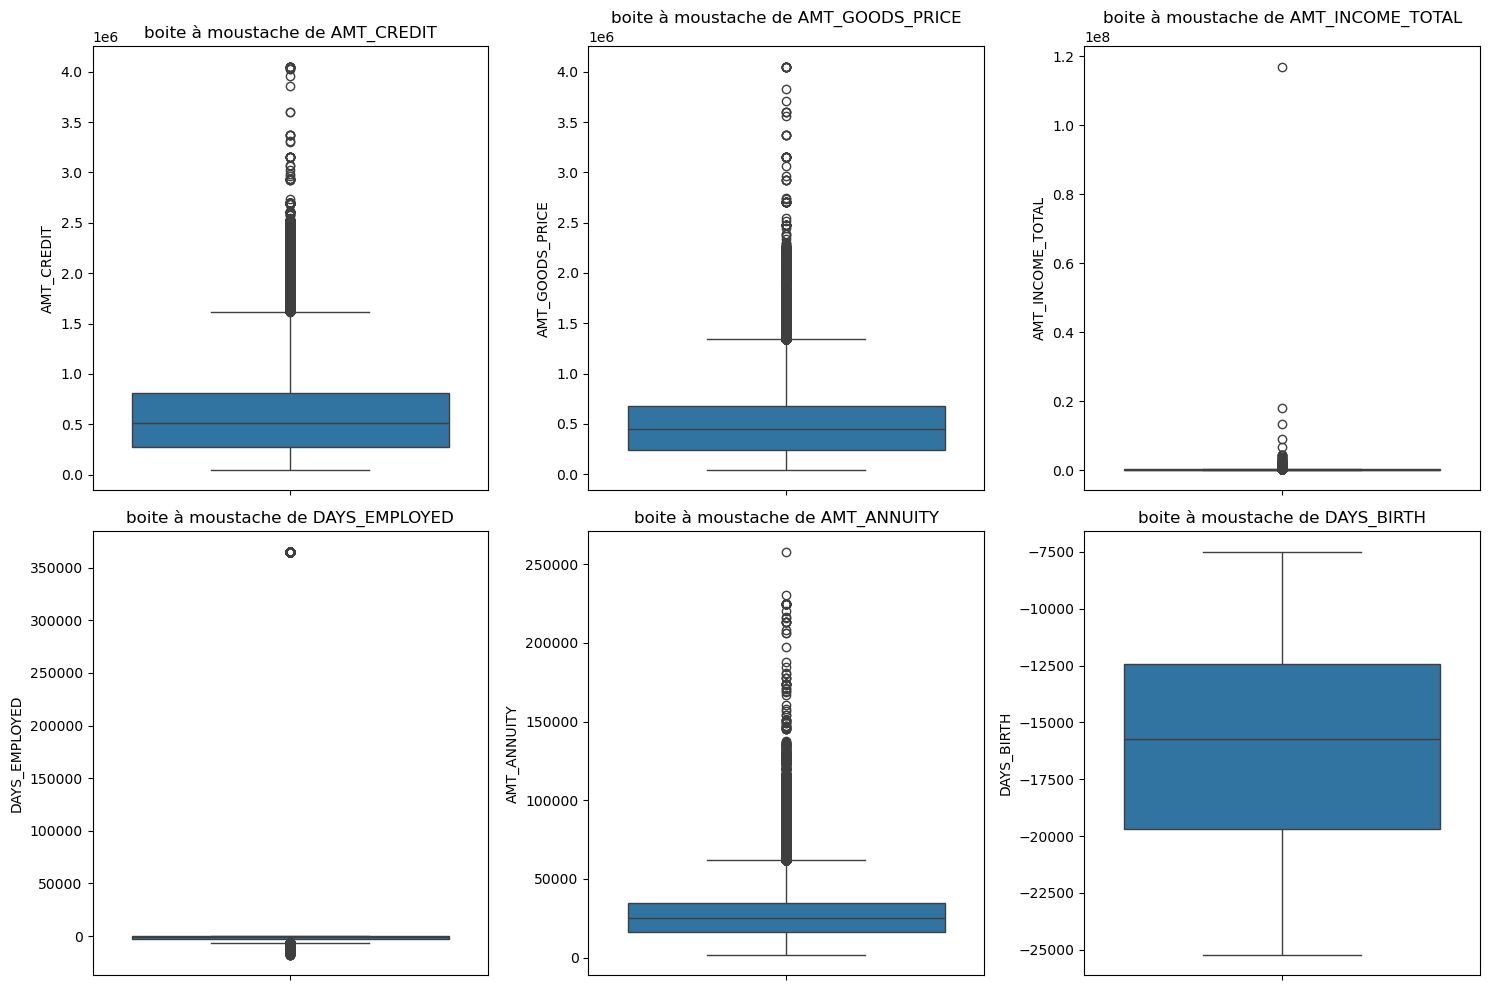

In [45]:
# Boxplots pour détecter les outliers
important_features = top_variance_features.index[:6]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(important_features):
    plt.subplot(2, 3,i+1)
    sns.boxplot(df[feature])
    plt.title(f'boite à moustache de {feature}')
    
plt.tight_layout()
plt.show()

on constate ici que les features avec une grande variances on aussi une certaine tendance a avoir beaucoup de valeur aberante

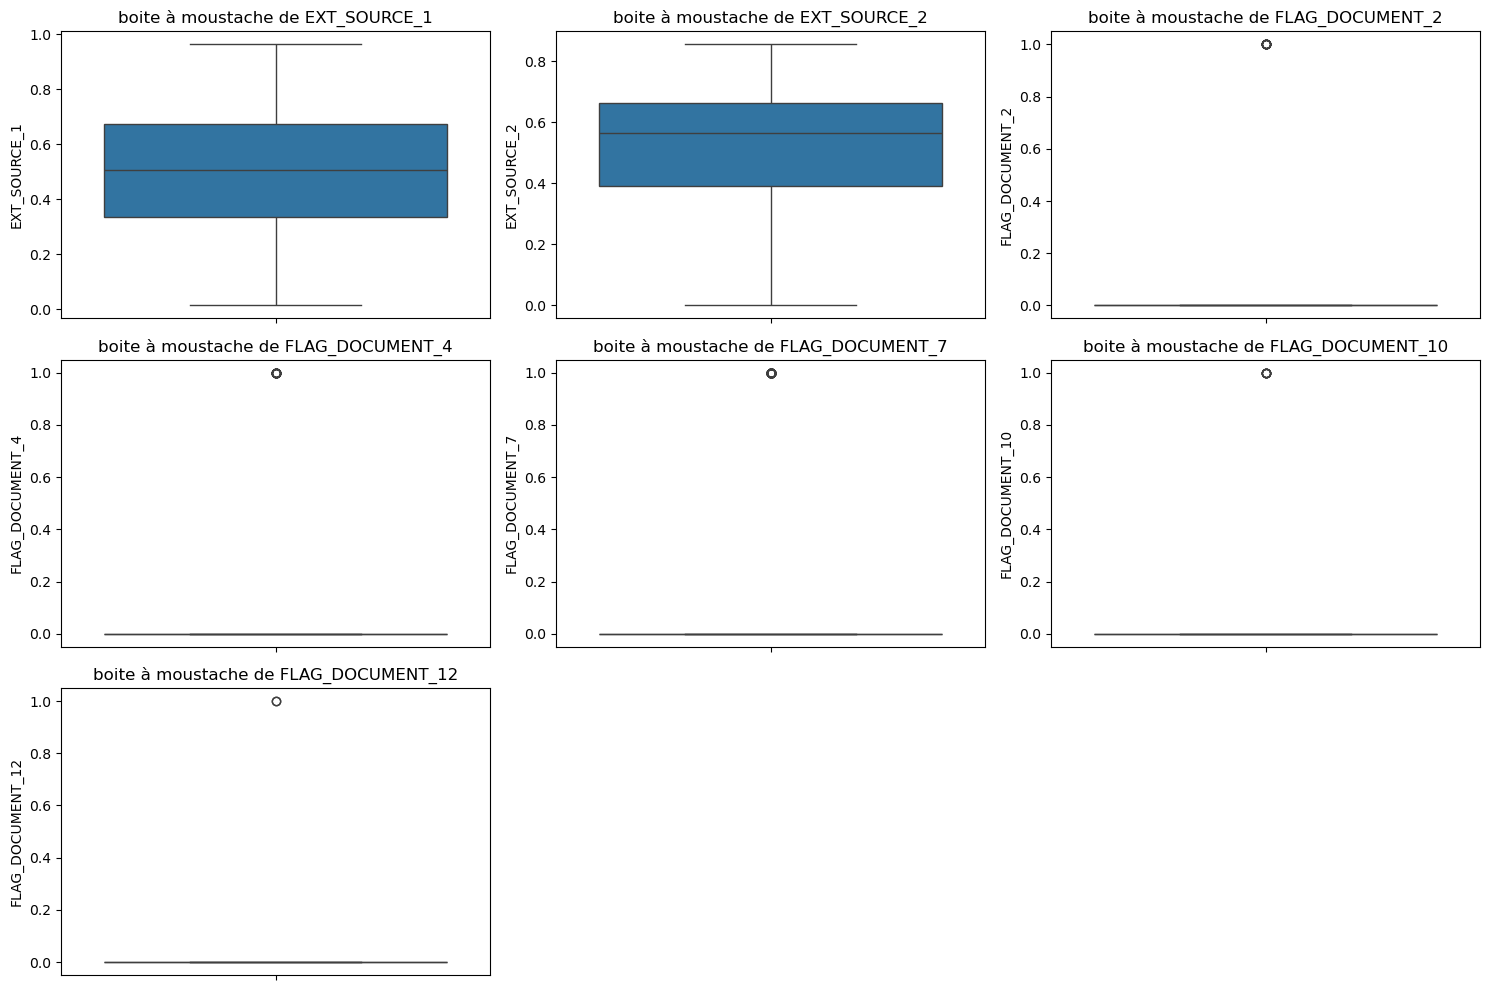

In [46]:
# Boxplots pour détecter les outliers
#important_features = top_variance_features.index[:6]

plt.figure(figsize=(15, 10))
for i, feature in enumerate(variables_numeriques_importantes):
    plt.subplot(3, 3,i+1)
    sns.boxplot(df[feature])
    plt.title(f'boite à moustache de {feature}')
    
plt.tight_layout()
plt.show()

on constate ici que les variables selectionner a partir de la variance et du skewness ont quant'a eux tendance a ne pas contenir de valeur aberante ou d'en contenir tres peu

### **REALISATION DES GRAPHIQUES :**

    nous allons implementer une fonction qui realise un certains nombre de graphiques en fonction de la liste des variables qui lui est passee en parametre

In [47]:
def realiser_graphiques(df, variables):
    """"
    Realise des graphiques pour les variables specifiees

    parametres :
    df(DataFrame) : le Dataframe contenant les donnees 
    variables (list) : la liste des variables(des features) pour lesquels on veut realiser des graphiques 
    """

    # Boucle sur les variables/les features
    for variable in variables:
        #verification du type de la variable
        if df[variable].dtype == 'object':
            # graphique de bar pour les variables categorielles
            plt.figure(figsize=(8, 6))
            sns.countplot(x=variable, data=df)
            plt.title(f"Distribution de {variable}")
            plt.show()

            #Graphique de pie pour les variables categorielles
            plt.figure(figsize=(8, 6))
            df[variable].value_counts().plot(kind='pie', autopct='%1.1f%%')
            plt.title(f"Proportion de {variable}")
            plt.show()
        else:
            #histogamme pour les variables numeriques
            plt.figure(figsize=(8, 6))
            sns.histplot(df[variable], kde=True)
            plt.title(f"Distribution de {variable}")
            plt.show()

            # Boxplotpour les ariables nimeriques
            plt.figure(figsize=(8, 6))
            sns.boxplot(df[variable])
            plt.title(f"boxplot de {variable}")
            plt.show()

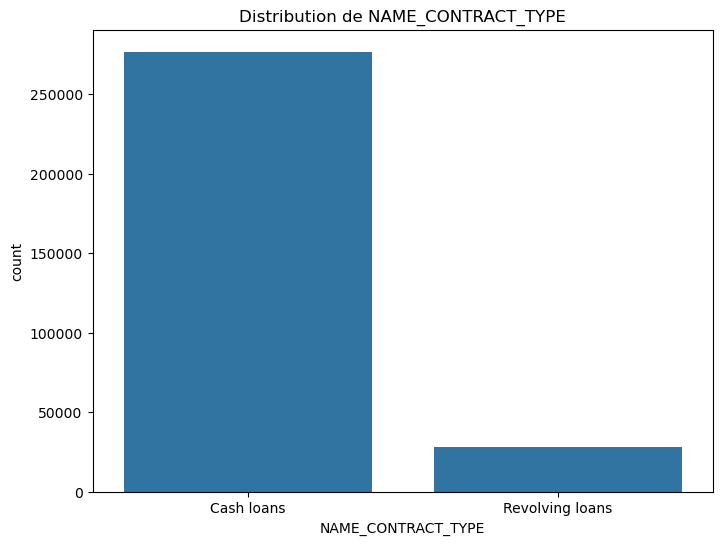

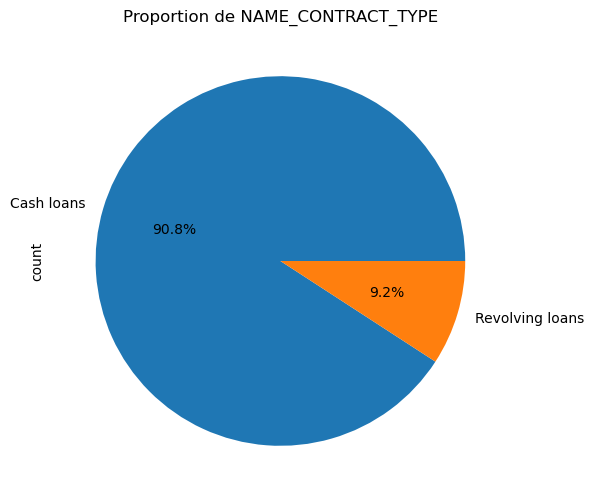

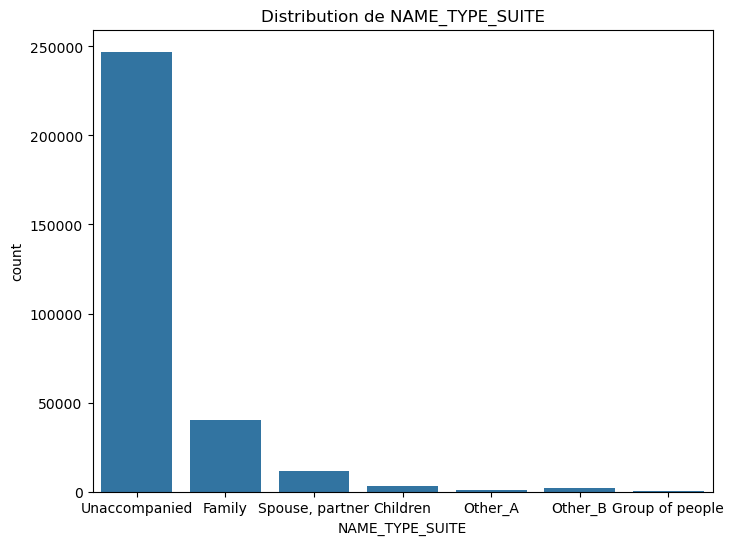

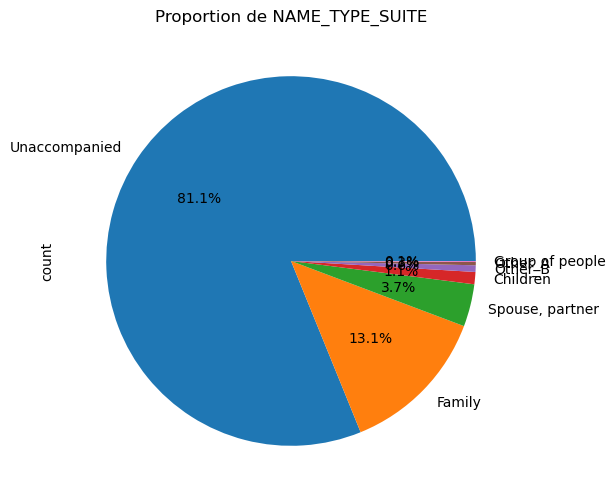

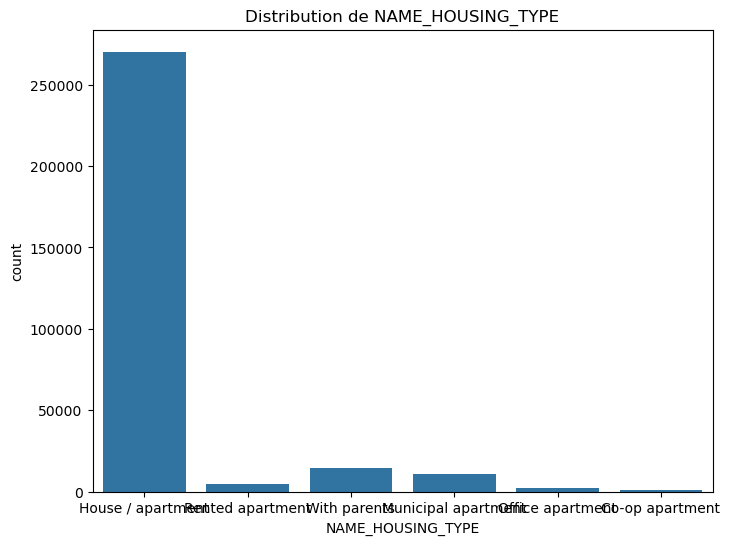

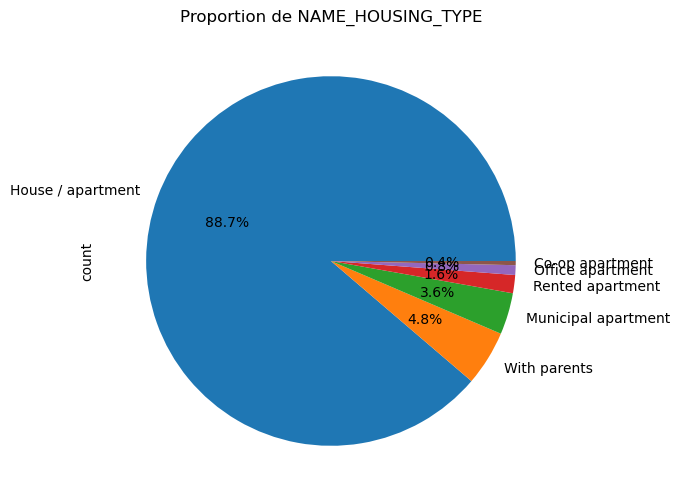

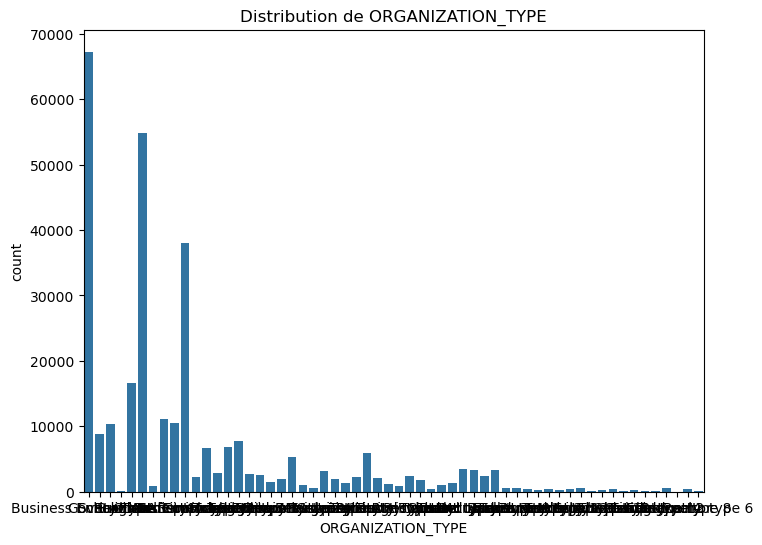

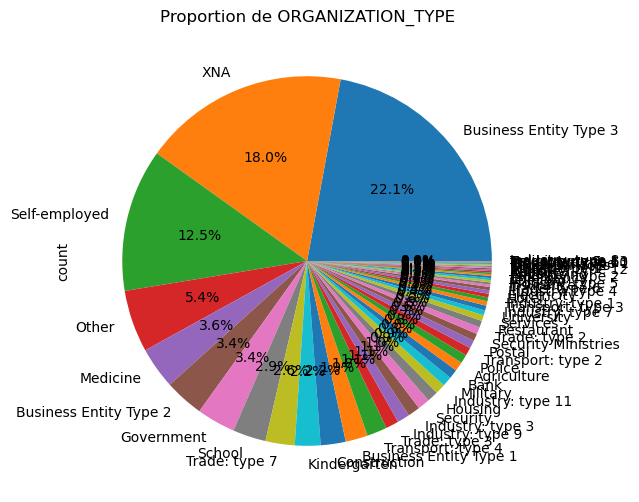

In [48]:
#vutilisation de la fonction realiser_graphiques pour afficher les graphiques des variables/features les plus importantes

variables_object = selectionner_variables_object_importantes(df_traite)

realiser_graphiques(df_traite, variables_object)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16400\1588181245.py:24: RuntimeWarning: invalid value encountered in scalar divide
  skewness.append( np.abs( np.mean((encoded_colonne - np.mean(encoded_colonne))**3) / np.std(encoded_colonne)**3))


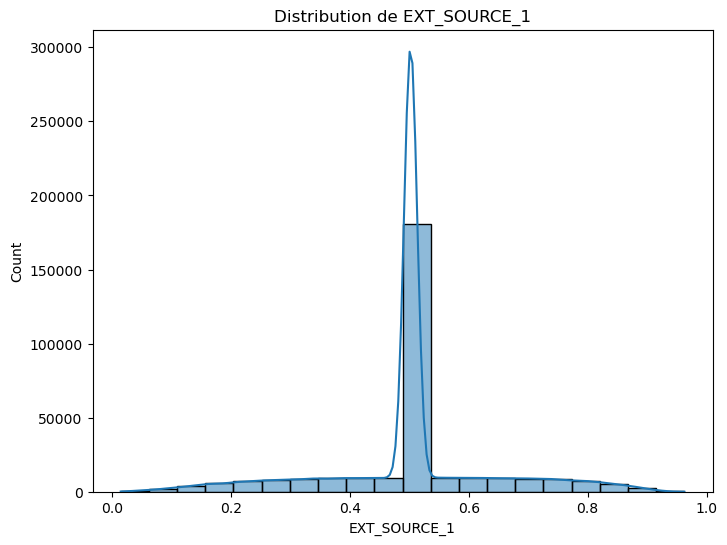

KeyboardInterrupt: 

In [49]:
variables_numeriques = selectionner_variables_importantes(df_traite)

realiser_graphiques(df_traite, variables_numeriques)



#### **MATRICE DE CORRELATION :**



#### **notes :**  

- nous ne pouvions precedement pas realiser la matrice de correlation cars notre echantillon n'etais encore ni standardiser ni nomaliser

- arriver a l'etape de pretraitement on a deja encoder(standardiser et normaliser) l'echantillon a partir de la on peut donc realiser la matrice de correlation afin d'identifier quelles sont les variables explicatives qui influences le plus la variables expliquee 
- pour realiser cela nous allons : 
    - implementer une fonction correlation_features_target (df, target) qui : 
        -  realise la matrice de correlation du dataframe qu'elle prend en paramettre 
        -  selectionne directement les features qui influence le plus la target

In [ ]:
def correlation_features_target(df, target):
    """
    Réalise la matrice de corrélation et sélectionne les features qui influencent le plus la target.
    Paramètres :
    df (DataFrame) : Le DataFrame contenant les données.
    target (str) : Le nom de la colonne target.
    Retourne :
    features_importantes (list) : La liste des features qui influencent le plus la target.
    """
    # Calcul de la matrice de corrélation
    #corr_matrix = df.corr(numeric_only=True)
    corr_matrix = df.select_dtypes(include=[np.number]).corr()
    # Sélection des features qui influencent le plus la target
    features_importantes = corr_matrix[target].abs().sort_values(ascending=False)[1:].head(20)
    # Affichage de la matrice de corrélation
    plt.figure(figsize=(100, 80))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
    plt.title("Matrice de corrélation")
    plt.show()
    # Affichage des features qui influencent le plus la target
    print("Features qui influencent le plus la target :")
    print(features_importantes)
    return features_importantes.index.tolist()

In [ ]:
# Calcul de la matrice de corrélation
#corr_matrix = df.corr(numeric_only=True)
corr_matrix = df.select_dtypes(include=[np.number]).corr()
# Sélection des features qui influencent le plus la target
features_importantes = corr_matrix['TARGET'].abs().sort_values(ascending=False)[1:].head(20)
# Affichage de la matrice de corrélation
plt.figure(figsize=(100, 80))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Matrice de corrélation")
plt.show()
# Affichage des features qui influencent le plus la target
print("Features qui influencent le plus la target :")
print(features_importantes)




## **1.2- PRETRAITEMENT**






### **OBSERVATIONS :**

    nous constatons qu'il y a pas mal de variables de types objet ces dernieres pourrait etre d'une grande importance lors de l'entrainement du modele, on ne peut donc pas se contenter de les supprimer

    ce que nous allons faire c'est que nous allons implementer une fonction qui prend un dataframe en paramentre et retourne le meme dataframe avec toutes les variables categoriels transformer en variables numerique






#### **ENCODAGE DU DATASET :**


#### **NOTES :**

- afin de mettre les donnees presente dans notre echantillon sous la meme `echelle` et selon les memes `standard` nous allons y appiquer un enssemble d'operation qu'on appele communement l'`encodage`
- pour ce faire nous allons implementer :
    - une fonction encoder_variables_objet (df) qui encode les variables de type objet en variables de type numerique
    - une fonction .... qui mets tout les element present dans l'echantillon sous la meme echelle

In [ ]:
def encoder_variables_objet (df) :# IMPLEMENTATION DE LA FONCTION D'ENCODAGE
    """
    encode les variables de types objet en variables de type numerique

    parametres : 
    df (Dataframe) : le dataframe a encoder

    Retourne : 
    df_encode (Dataframe) : le dataframe avec les variables objects encodees
    """

    df_encode = df.copy()
    colonnes_object = df_encode.select_dtypes(include=['object']).columns

    for colonne in colonnes_object:
        le = LabelEncoder()
        df_encode[colonne] = le.fit_transform(df_encode[colonne])

    return df_encode
    


In [ ]:
def preprocessing_df(df):
    """
    Réalise le preprocessing d'un dataframe.
    Paramètres :
    df (DataFrame) : Le DataFrame à preprocesser.
    Retourne :
    df_preprocesse (DataFrame) : Le DataFrame preprocessé.
    """
    # Séparation des colonnes numériques et catégorielles
    colonnes_numeriques = df.select_dtypes(include=['int64', 'float64']).columns
    colonnes_categorielles = df.select_dtypes(include=['object']).columns
    # Traitement des valeurs manquantes
    # imputer_numerique = SimpleImputer(strategy='mean')
    # imputer_categoriel = SimpleImputer(strategy='most_frequent')
    # df[colonnes_numeriques] = imputer_numerique.fit_transform(df[colonnes_numeriques])
    # df[colonnes_categorielles] = imputer_categoriel.fit_transform(df[colonnes_categorielles])
    # Encodage des variables catégorielles
    #encoder = OneHotEncoder(sparse=False)
    encoder = OneHotEncoder()
    df_categoriel = pd.DataFrame(encoder.fit_transform(df[colonnes_categorielles]), columns=encoder.get_feature_names_out())
    # Normalisation des variables numériques
    scaler = StandardScaler()
    df[colonnes_numeriques] = scaler.fit_transform(df[colonnes_numeriques])
    # Concaténation des données
    df_preprocesse = pd.concat([df[colonnes_numeriques], df_categoriel], axis=1)
    return df_preprocesse

In [ ]:
# 8. Gestion des outliers
# a) Identifier les outliers avec la règle IQR (1.5×IQR)
def identify_outliers_iqr(data, feature):
    outlier_indices = set()
    for col in feature:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.update(outliers)
    return list(outlier_indices)

In [ ]:
num_features = df_numeric_only.drop(columns="TARGET", axis=1).columns
outliers_idx = identify_outliers_iqr(df_traite, num_features)

print(f"Nombre totale d'observations: {len(outliers_idx)}") 

#### b) Décider de la stratégie : suppression ou imputation
#### Ici, nous choisissons l'imputation par clipping(winsorization) 

In [ ]:
# c) Appliquer la stratégie choisie
df_outliers_handled = df_traite.copy()

for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_outliers_handled[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
print(df_outliers_handled)


---

# **2- MODELISATION :**
- test de plusieurs algorithmes (regression logisstique, forets aleatoires, XGBoost, LightGBM,...)
- optimisation des hyperparametres.
- validation croisee pour assurer la robustesse du modele.

In [ ]:
def entrainer_algorithmes(df, target, algorithmes):
    """
    Entraîne un dataframe sur une liste d'algorithmes.
    Paramètres :
    df (DataFrame) : Le DataFrame à entraîner.
    target (str) : Le nom de la colonne target.
    algorithmes (list) : La liste des algorithmes à entraîner.
    Retourne :
    resultats (dict) : Un dictionnaire contenant les résultats de chaque algorithme.
    """
    # Séparation des données en entraînement et test
    X = df.drop(target, axis=1)
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    # Dictionnaire des algorithmes
    algo_dict = {
        'LogisticRegression': LogisticRegression(),
        'DecisionTreeClassifier': DecisionTreeClassifier(),
        'RandomForestClassifier': RandomForestClassifier(),
        'SVC': SVC(),
        'KNeighborsClassifier': KNeighborsClassifier()
    }
    # Entraînement des algorithmes
    resultats = {}
    for algo_name in algorithmes:
        algo = algo_dict[algo_name]
        algo.fit(X_train, y_train)
        y_pred = algo.predict(X_test)
        resultats[algo_name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred),
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }
    return resultats


In [ ]:
def encoder_variables_object (df) :
    """
    encode les variables de types objet en variables de type numerique

    parametres : 
    df (Dataframe) : le dataframe a encoder

    Retourne : 
    df_encode (Dataframe) : le dataframe avec les variables objects encodees
    """

    df_encode = df.copy()
    colonnes_object = df_encode.select_dtypes(include=['object']).columns

    for colonne in colonnes_object:
        le = LabelEncoder()
        df_encode[colonne] = le.fit_transform(df_encode[colonne])

    return df_encode

In [ ]:
target = 'target'
algorithmes = ['LogisticRegression', 'DecisionTreeClassifier', 'RandomForestClassifier']
resultats = entrainer_algorithmes(df, target, algorithmes)
for algo_name, resultat in resultats.items():
    print(f"Algorithme : {algo_name}")
    print(f"Accuracy : {resultat['accuracy']}")
    print(f"Rapport de classification : \n{resultat['classification_report']}")
    print(f"Matrice de confusion : \n{resultat['confusion_matrix']}")
    print("------------------------")

### Preparation des donnees

In [ ]:
# 1- preparation des donnees

data = encoder_variables_object(df_outliers_handled)


# Séparation train/test
X = data.drop('TARGET', axis=1)
y = data['TARGET']  
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_test, X_train)

In [ ]:
# 2. Modèle de baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modèle aléatoire
random_clf = DummyClassifier(strategy='uniform', random_state=42)
random_clf.fit(X_train, y_train)
y_pred_random = random_clf.predict(X_test)
acc_random = accuracy_score(y_test, y_pred_random)

# Modèle majoritaire
majority_clf = DummyClassifier(strategy='most_frequent', random_state=42)
majority_clf.fit(X_train, y_train)
y_pred_majority = majority_clf.predict(X_test)
acc_majority = accuracy_score(y_test, y_pred_majority)

print("="*50)
print("MODÈLES BASELINE")
print("="*50)
print(f"Modèle aléatoire - Accuracy: {acc_random:.3f}")
print(f"Modèle majoritaire - Accuracy: {acc_majority:.3f}")
print(f"\nDistribution des classes dans y_test:")
print(f"Classe 0 (bénin): {(y_test == 0).sum()} échantillons")
print(f"Classe 1 (malin): {(y_test == 1).sum()} échantillons")


In [ ]:
# 3. Fonction d'évaluation complète
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name=""):
    """Évalue un modèle avec plusieurs métriques"""
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calcul des métriques
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    
    # Affichage
    print(f"\n{'='*50}")
    print(f"ÉVALUATION: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {metrics['accuracy']:.3f}")
    print(f"Precision: {metrics['precision']:.3f}")
    print(f"Recall:    {metrics['recall']:.3f}")
    print(f"F1-Score:  {metrics['f1']:.3f}")
    
    print(f"\nMatrice de confusion:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matrice de confusion - {model_name}')
    plt.ylabel('Vrai label')
    plt.xlabel('Prédiction')
    plt.show()
    
    print(f"\nRapport de classification:")
    print(classification_report(y_test, y_pred, target_names=['mauvais payeur', 'bon payeur']))
    
    return metrics, y_pred, y_pred_proba

### Implémentation des Modèles

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb


In [ ]:
# Initialisation des modèles
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(probability=True, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


# Stockage des résultats
results = []
predictions = {}

# Entraînement et évaluation
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Entraînement du modèle: {name}")
    print(f"{'='*60}")
    
    metrics, y_pred, y_pred_proba = evaluate_model(
        model, X_train, X_test, y_train, y_test, name
    )
    
    results.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1']
    })
    
    predictions[name] = (y_pred, y_pred_proba)


In [ ]:

# 5. Analyse comparative
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("COMPARAISON DES MODÈLES")
print(f"{'='*60}")

# Affichage du tableau comparatif
print(results_df.sort_values('F1-Score', ascending=False).to_string(index=False))

# Visualisation des résultats
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx//2, idx%2]
    sorted_df = results_df.sort_values(metric)
    ax.barh(sorted_df['Model'], sorted_df[metric])
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} par modèle')
    ax.set_xlim([0, 1])
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(sorted_df[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# Identification du meilleur modèle selon F1-Score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1_score = results_df.loc[results_df['F1-Score'].idxmax(), 'F1-Score']
print(f"\n Meilleur modèle (F1-Score): {best_model_name} avec F1-Score = {best_f1_score:.3f}")


---

# **3- INTERPRETATION ET EVALUATION :** 
- METRIQUES CLES : auc-roc, PRECISION, RAPPEL, f1-SCORE
- analyse des features importantes
- explicabilite du modele (SHAP, LIME)

# **3.1- METRIQUES CLES : auc-roc, PRECISION, RAPPEL, f1-SCORE :**

# **3.2- analyse des features importantes :**

# **3-3- explicabilite du modele (SHAP, LIME) :**


---

# **4- deploiement et monitoring (MLOps)**
- packaging du modele 
- creation d'une API de prediction (confert src/app.py)
- mise en place de pipelines de reentrainement et de monitoring des performances (en attente)

# **4-1 packaging du modele :**